# Project 
## Global Human Rights Index (V-Dem) - Exploratory Data Analysis

In [19]:
import pandas as pd
df=pd.read_csv(r"c:\Users\user\Desktop\Datasets To Upload Kaggle\human-rights-index-vdem.csv")

# Data Info 

In [20]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())

Shape: (34753, 5)

Columns:
 Index(['Entity', 'Code', 'Year', 'Human Rights Index',
       'World region according to OWID'],
      dtype='object')

Data Types:
 Entity                             object
Code                               object
Year                                int64
Human Rights Index                float64
World region according to OWID     object
dtype: object

Missing Values:
 Entity                               0
Code                              2965
Year                                 0
Human Rights Index                   0
World region according to OWID    4246
dtype: int64

Summary Statistics:
                Year  Human Rights Index
count  34753.000000        34753.000000
mean    1924.434495            0.441576
std       65.074774            0.272277
min     1789.000000            0.009000
25%     1872.000000            0.209000
50%     1933.000000            0.385000
75%     1979.000000            0.656000
max     2024.000000            0.976000


# Data Handling and Cleaning

In [21]:
df.isna().sum()

Entity                               0
Code                              2965
Year                                 0
Human Rights Index                   0
World region according to OWID    4246
dtype: int64

In [23]:
df = df.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Human Rights Index": "hri",
    "World region according to OWID": "region"
})


In [25]:
import numpy as np
import matplotlib.pyplot as plt


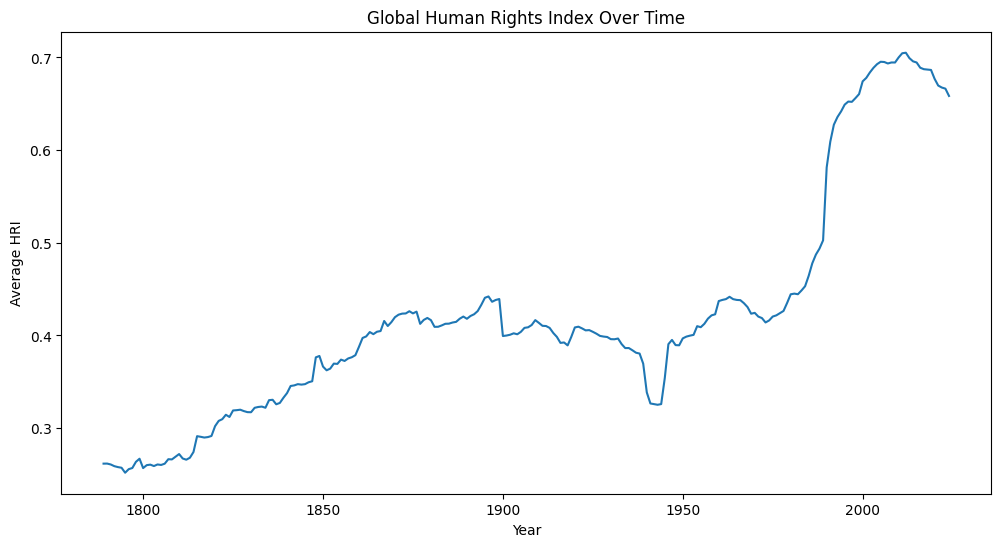

In [ ]:
df = df.dropna(subset=["hri"])
df["year"] = df["year"].astype(int)

# EDA & Visualization

In [ ]:
# 6. Global Trend Over Time
global_trend = df.groupby("year")["hri"].mean()

plt.figure(figsize=(12,6))
plt.plot(global_trend.index, global_trend.values)
plt.title("Global Human Rights Index Over Time")
plt.xlabel("Year")
plt.ylabel("Average HRI")
plt.show()


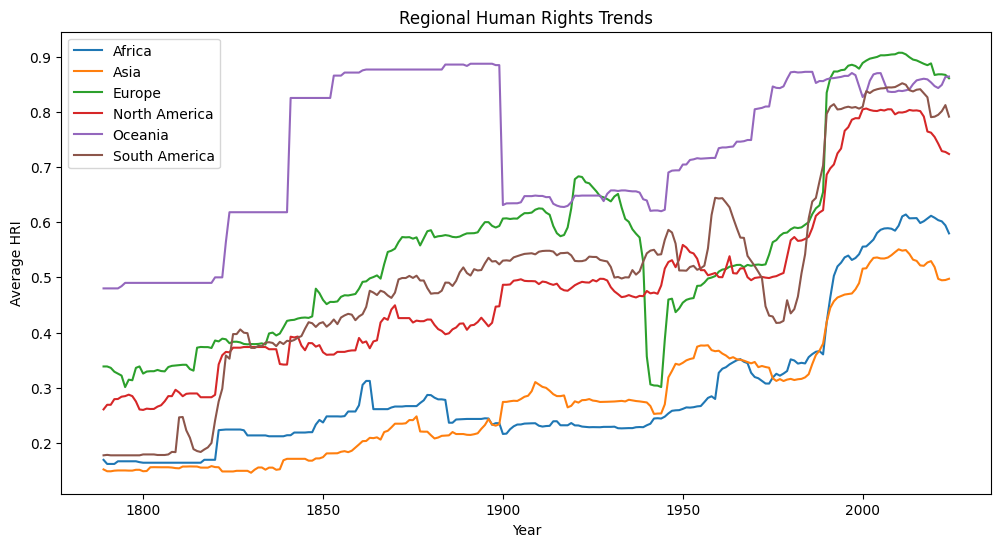

In [29]:
# 7. Regional Trends
regional_trend = df.groupby(["year", "region"])["hri"].mean().unstack()

plt.figure(figsize=(12,6))
for col in regional_trend.columns:
    plt.plot(regional_trend.index, regional_trend[col], label=col)

plt.title("Regional Human Rights Trends")
plt.xlabel("Year")
plt.ylabel("Average HRI")
plt.legend()
plt.show()


In [30]:
# 8. Top 10 Countries (Latest Year)
latest_year = df["year"].max()
latest_df = df[df["year"] == latest_year]

top10 = latest_df.sort_values("hri", ascending=False).head(10)
print("\nTop 10 Countries (Latest Year):\n", top10[["country", "hri"]])


Top 10 Countries (Latest Year):
            country    hri
9534       Estonia  0.960
29612       Sweden  0.960
7862       Denmark  0.959
14851      Ireland  0.956
21221  New Zealand  0.956
7470       Czechia  0.955
3348       Belgium  0.955
29839  Switzerland  0.954
13730      Iceland  0.949
28937        Spain  0.948


In [31]:
# 9. Bottom 10 Countries (Latest Year)
bottom10 = latest_df.sort_values("hri", ascending=True).head(10)
print("\nBottom 10 Countries (Latest Year):\n", bottom10[["country", "hri"]])


Bottom 10 Countries (Latest Year):
               country    hri
22244     North Korea  0.019
235       Afghanistan  0.042
9298          Eritrea  0.048
21408       Nicaragua  0.084
20452         Myanmar  0.105
23450  Palestine/Gaza  0.107
31643    Turkmenistan  0.109
30073           Syria  0.121
16734            Laos  0.148
26037    Saudi Arabia  0.173


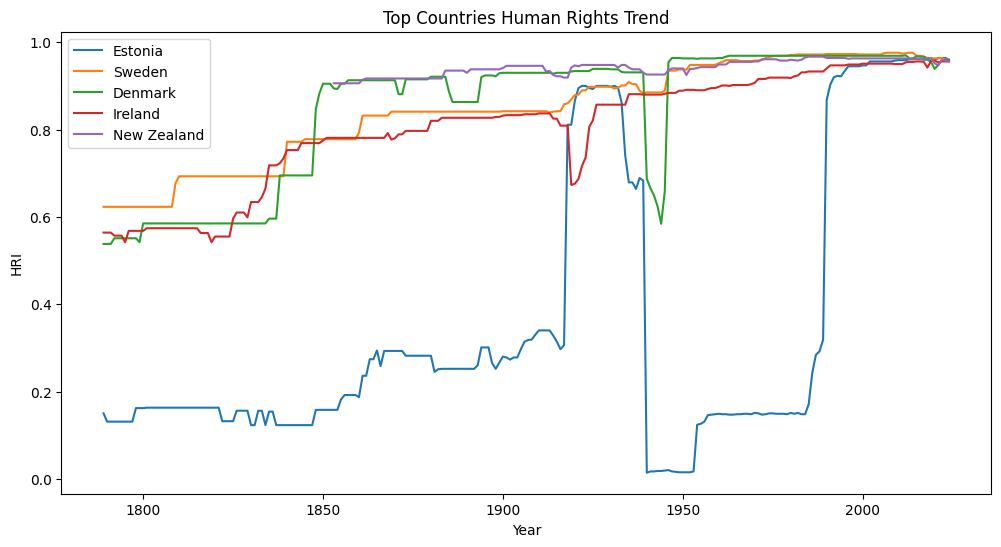

In [34]:
# 10. Country-wise Trend Example (Top 5 Countries)
top_countries = top10["country"].values[:5]
plt.figure(figsize=(12,6))
for country in top_countries:
    subset = df[df["country"] == country]
    plt.plot(subset["year"], subset["hri"], label=country)

plt.title("Top Countries Human Rights Trend")
plt.xlabel("Year")
plt.ylabel("HRI")
plt.legend()
plt.show()

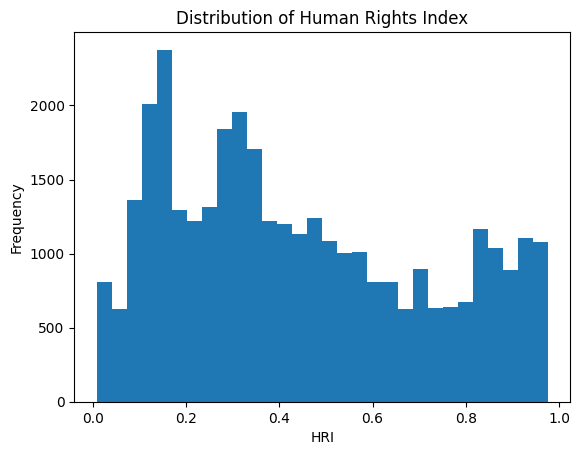

In [35]:
# 11. Distribution of Human Rights Index
plt.figure()
plt.hist(df["hri"], bins=30)
plt.title("Distribution of Human Rights Index")
plt.xlabel("HRI")
plt.ylabel("Frequency")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_14264\2860164351.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=regions)


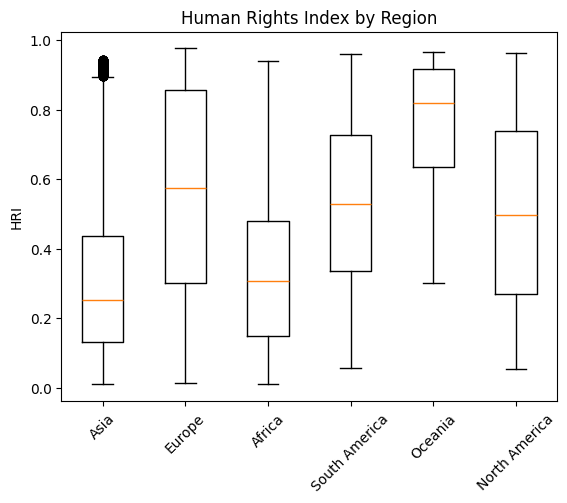

In [36]:
# 12. Regional Comparison (Boxplot)
regions = df["region"].dropna().unique()
data = [df[df["region"] == r]["hri"] for r in regions]

plt.figure()
plt.boxplot(data, labels=regions)
plt.xticks(rotation=45)
plt.title("Human Rights Index by Region")
plt.ylabel("HRI")
plt.show()

In [37]:
# 13. Growth Analysis (Country Improvement)
first_year = df["year"].min()
last_year = df["year"].max()

start = df[df["year"] == first_year][["country", "hri"]].rename(columns={"hri": "start_hri"})
end = df[df["year"] == last_year][["country", "hri"]].rename(columns={"hri": "end_hri"})

growth = pd.merge(start, end, on="country", how="inner")
growth["change"] = growth["end_hri"] - growth["start_hri"]

top_improved = growth.sort_values("change", ascending=False).head(10)
top_declined = growth.sort_values("change", ascending=True).head(10)

print("\nTop Improved Countries:\n", top_improved)
print("\nTop Declined Countries:\n", top_declined)


Top Improved Countries:
         country  start_hri  end_hri  change
33        Japan      0.091    0.928   0.837
10        Chile      0.098    0.932   0.834
49     Portugal      0.083    0.901   0.818
18      Estonia      0.150    0.960   0.810
58       Taiwan      0.123    0.932   0.809
37       Latvia      0.150    0.939   0.789
54  South Korea      0.086    0.837   0.751
40      Moldova      0.150    0.868   0.718
8        Brazil      0.134    0.850   0.716
24      Germany      0.228    0.941   0.713

Top Declined Countries:
          country  start_hri  end_hri  change
0    Afghanistan      0.121    0.042  -0.079
45   North Korea      0.086    0.019  -0.067
57         Syria      0.177    0.121  -0.056
17         Egypt      0.312    0.266  -0.046
36          Laos      0.162    0.148  -0.014
11         China      0.123    0.186   0.063
51  Saudi Arabia      0.099    0.173   0.074
13          Cuba      0.188    0.293   0.105
38         Libya      0.226    0.332   0.106
50        Russ

In [38]:
# 14. Correlation Matrix
numeric_df = df[["year", "hri"]]

corr = numeric_df.corr()
print("\nCorrelation Matrix:\n", corr)



Correlation Matrix:
           year       hri
year  1.000000  0.371597
hri   0.371597  1.000000


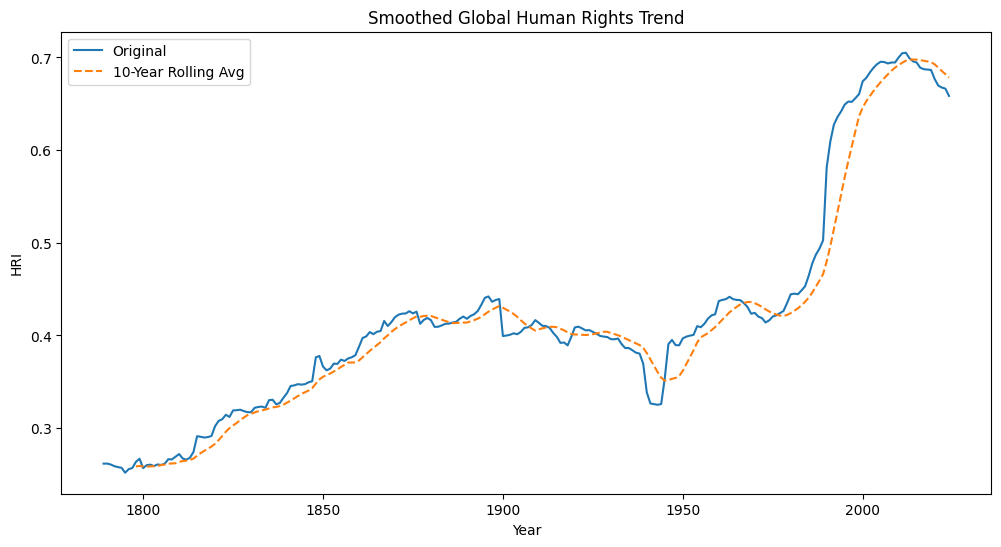

In [ ]:
# 15. Rolling Average Trend (Smoothing)
rolling_trend = global_trend.rolling(window=10).mean()

plt.figure(figsize=(12,6))
plt.plot(global_trend.index, global_trend.values, label="Original")
plt.plot(rolling_trend.index, rolling_trend.values, linestyle="--", label="10-Year Rolling Avg")
plt.title("Smoothed Global Human Rights Trend")
plt.xlabel("Year")
plt.ylabel("HRI")
plt.legend()
plt.show()

